In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory SVD Factor Recovery
Running SVD on each of the three 25-portfolio dataframes *(ME/BEME, ME/INV, ME/OP)* should recover the latent risk factors. To verify, we correlate the three **left singular vectors** *(SVD_1, SVD_2, SVD_3)* against the FF5 factors.

In [43]:
PATH = '../data/processed'

# Tuple list of file names and labels
df_list = [("ff_portfolios_25_ME_BEME.parquet", "ME/BEME"),
           ("ff_portfolios_25_ME_INV.parquet", "ME/INV"),
           ("ff_portfolios_25_ME_OP.parquet", "ME/OP")]

# Loading processed ff5 factor df
ff5 = pd.read_parquet(f'{PATH}/ff5_factors_monthly.parquet')
# Filtering year range
ff5 = ff5[ff5['Date'].between('1963-07-01', '2013-12-31')].copy()
# Parsing as numeric
ff5 = ff5.set_index('Date').apply(pd.to_numeric, errors='coerce')

results = []

for fname, label in df_list:
    df = pd.read_parquet(f'{PATH}/{fname}')
    # Filtering year range
    df = df[df['Date'].between('1963-07-01', '2013-12-31')]
    # Setting index and parsing
    df = df.set_index('Date').apply(pd.to_numeric, errors='coerce')

    # Demeaning
    R = df - df.mean()
    # Running SVD
    U, sigma, Vt = np.linalg.svd(R, full_matrices=False)
    svd = pd.DataFrame(U[:,:3] * sigma[:3], index=df.index, columns=['SVD_1','SVD_2','SVD_3'])

    # Correlation matrix
    corr = svd.join(ff5).corr().loc[['SVD_1','SVD_2','SVD_3'], ['Mkt-RF','SMB','HML','RMW','CMA']]
    results.append((corr, label))
    print(f'\n{label} Correlation Matrix')
    print(corr)


ME/BEME Correlation Matrix
         Mkt-RF       SMB       HML       RMW       CMA
SVD_1 -0.932768 -0.586107  0.203799  0.294758  0.309162
SVD_2 -0.168991  0.604291 -0.574031 -0.310176 -0.312506
SVD_3 -0.265403  0.462936  0.752095 -0.124523  0.577588

ME/INV Correlation Matrix
         Mkt-RF       SMB       HML       RMW       CMA
SVD_1  0.937072  0.586841 -0.238195 -0.299590 -0.323312
SVD_2 -0.305628  0.770388  0.012664 -0.326223  0.084274
SVD_3  0.093461 -0.057452 -0.779823 -0.057529 -0.822797

ME/OP Correlation Matrix
         Mkt-RF       SMB       HML       RMW       CMA
SVD_1  0.940539  0.573676 -0.231539 -0.284454 -0.331480
SVD_2  0.299037 -0.772460 -0.084083  0.099494 -0.110408
SVD_3 -0.008780 -0.102120  0.273523  0.852719  0.029741


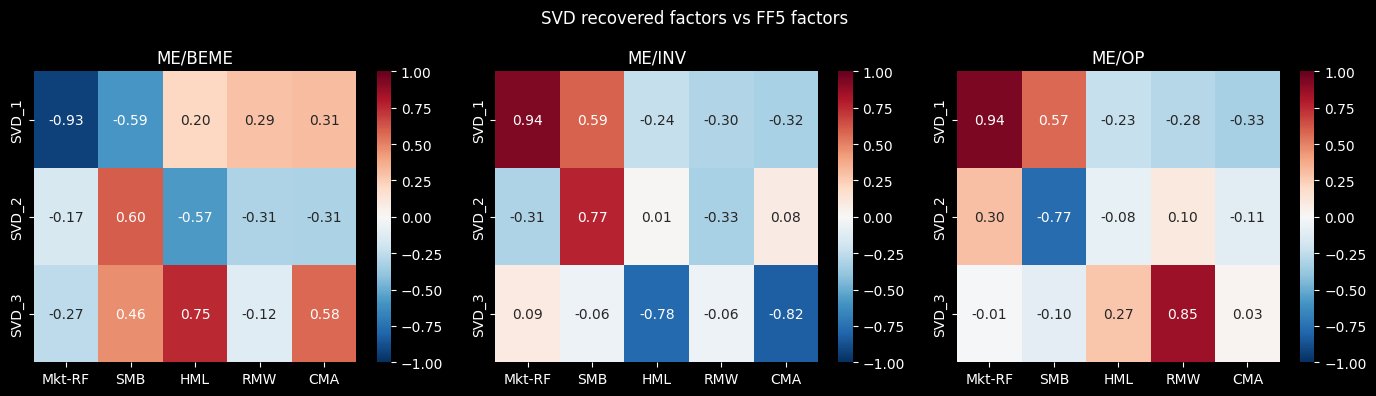

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (corr, label) in zip(axes, results):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(label)

plt.suptitle('SVD recovered factors vs FF5 factors')
plt.tight_layout()
plt.show()

# Results
+ SVD_1 recovers the **market factor** (r > |0.93|) across all three sorts.
+ SVD_2 consistently recovers **SMB** (0.60, 0.77, -0.77), since size is always the first sort dimension.
+ SVD_3 recovers the **sort-specific factor** in each case:
    + HML from ME/BEME (0.75)
    + CMA from ME/INV (-0.82)
    + RMW from ME/OP (0.85)

The results suggest the FF5 risk factors are **latent** in the return covariance matrix of the portfolios. They emerge endogenously from the data, independent of the theoretical framework of Fama and French.